Размер исходного датасета: (648511, 65)
Истинных электронов (MC) во всем датасете: 172982 (26.7%)

АНАЛИЗ ЭЛЕКТРОНОВ С НУЛЕВЫМ ИМПУЛЬСОМ
Всего электронов: 172982
Электронов с реконструированным p=0: 1183 (0.68%)
Электронов с MC импульсом = 0: 0 (0.00%)
Электронов с обоими импульсами = 0: 0

СТАТИСТИКА ВЫБОРОК
Обучающая выборка: 453957 событий
  Электронов: 121087 (26.7%)
  Фона: 332870
Тестовая выборка: 194554 событий
  Электронов: 51895 (26.7%)
  Фона: 142659

Классификационный отчет REC::Particle (ТЕСТОВАЯ ВЫБОРКА):
              precision    recall  f1-score   support

         Фон       0.95      1.00      0.98    142659
    Электрон       1.00      0.86      0.92     51895

    accuracy                           0.96    194554
   macro avg       0.97      0.93      0.95    194554
weighted avg       0.96      0.96      0.96    194554

Статистика CLAS12 на тестовой выборке (194554 событий):
True Positives (правильно найденные электроны): 44748
False Negatives (ПРОПУЩЕННЫЕ электроны)

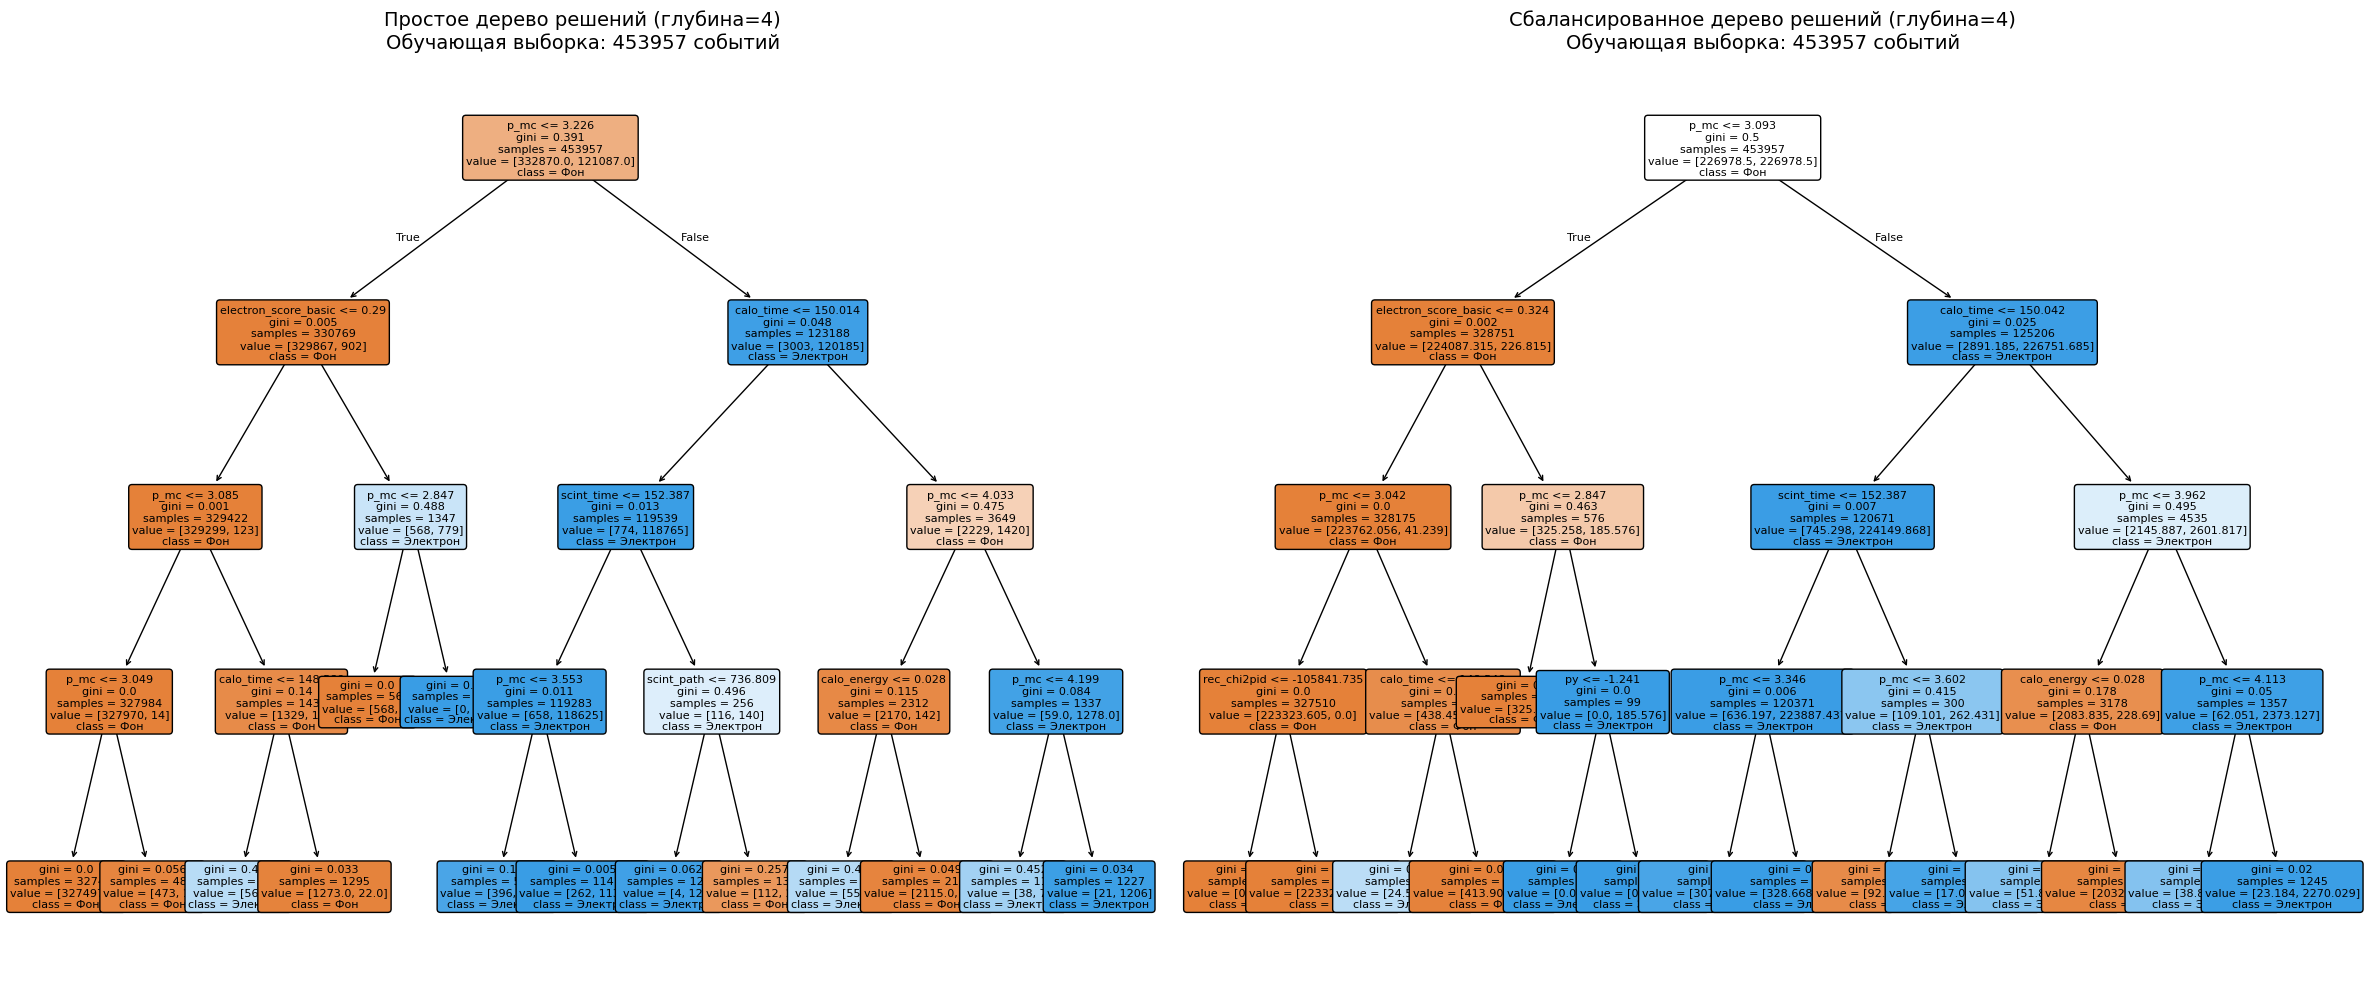


Топ-10 признаков для простого дерева:
                 feature  importance_simple
59                  p_mc           0.978086
15             calo_time           0.015220
55  electron_score_basic           0.005096
34            scint_time           0.000582
14           calo_energy           0.000532
35            scint_path           0.000484
58             ltcc_path           0.000000
44          track_sector           0.000000
33          scint_energy           0.000000
36            scint_chi2           0.000000

Топ-10 признаков для сбалансированного дерева:
                 feature  importance_balanced
59                  p_mc             0.989945
15             calo_time             0.008478
55  electron_score_basic             0.000596
34            scint_time             0.000278
14           calo_energy             0.000702
35            scint_path             0.000000
58             ltcc_path             0.000000
44          track_sector             0.000000
33          sci

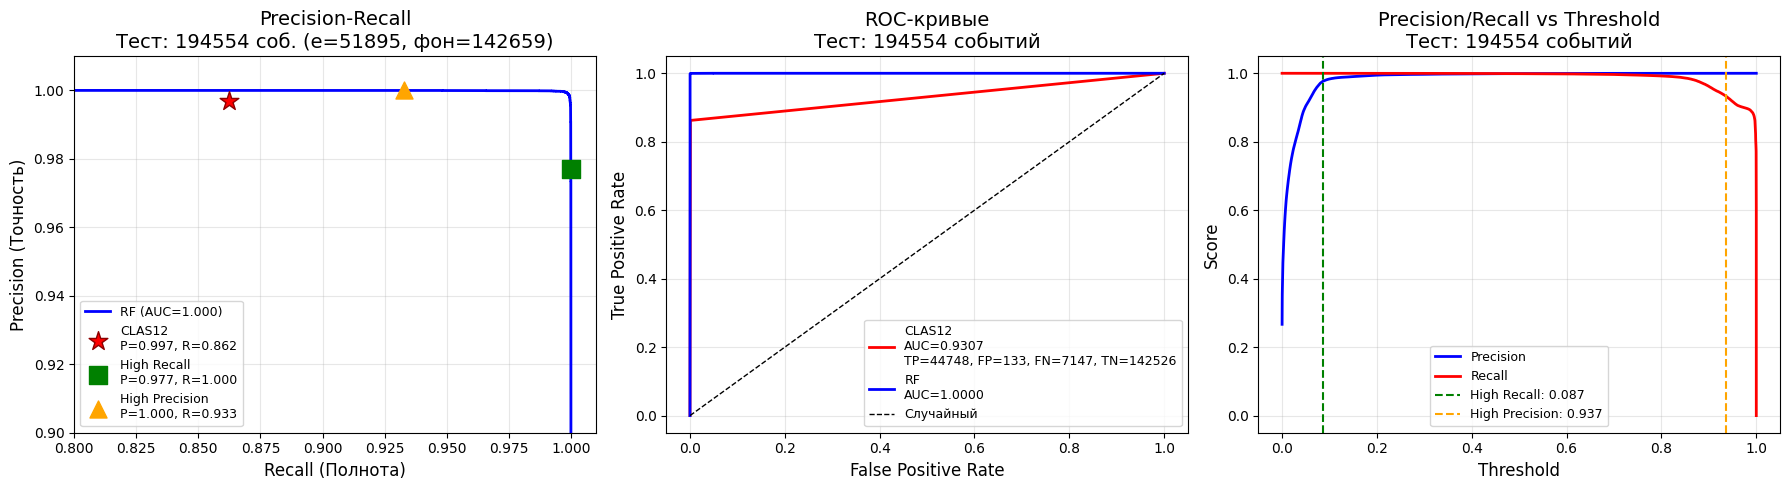


ГИСТОГРАММЫ ФИЗИЧЕСКИХ ВЕЛИЧИН (НОРМАЛЬНЫЙ МАСШТАБ)


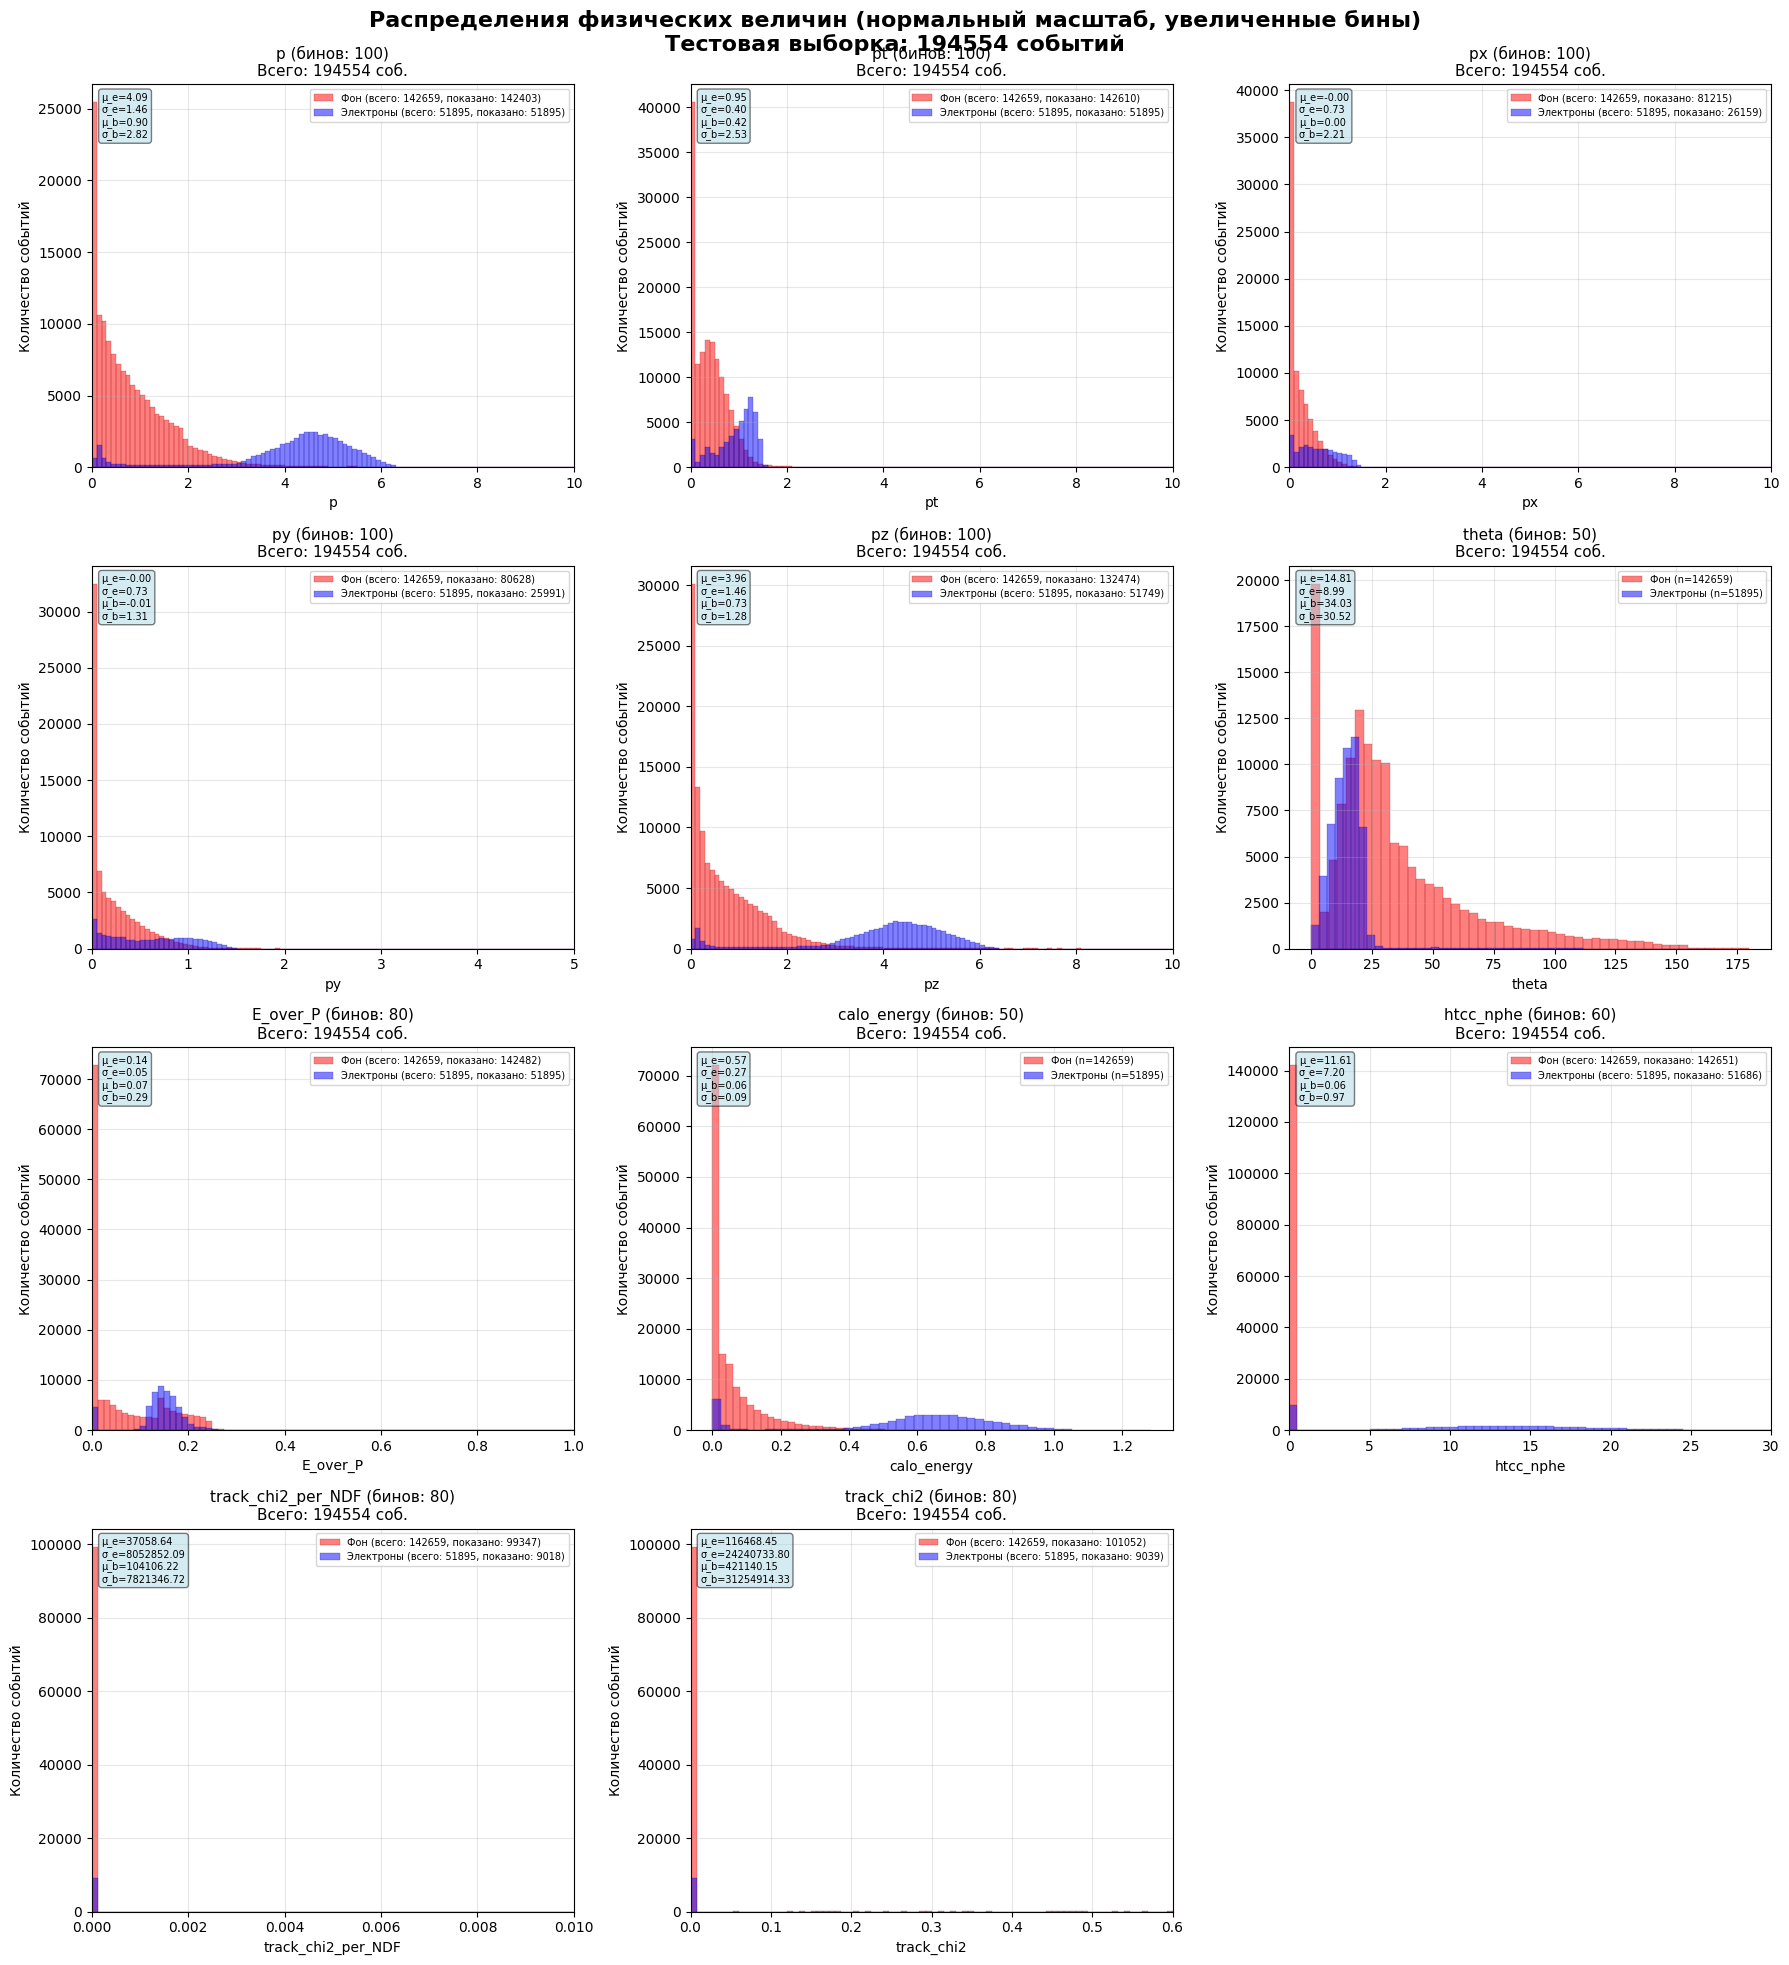


----------------------------------------
РЕЖИМ: УЛУЧШЕНИЕ RECALL
----------------------------------------
СПАСЕНО электронов: 7144 из 7147 пропущенных CLAS12 (+100.0%)
ДОБАВЛЕНО шума: 1102
Из них с p=0: 367 (5.1%)


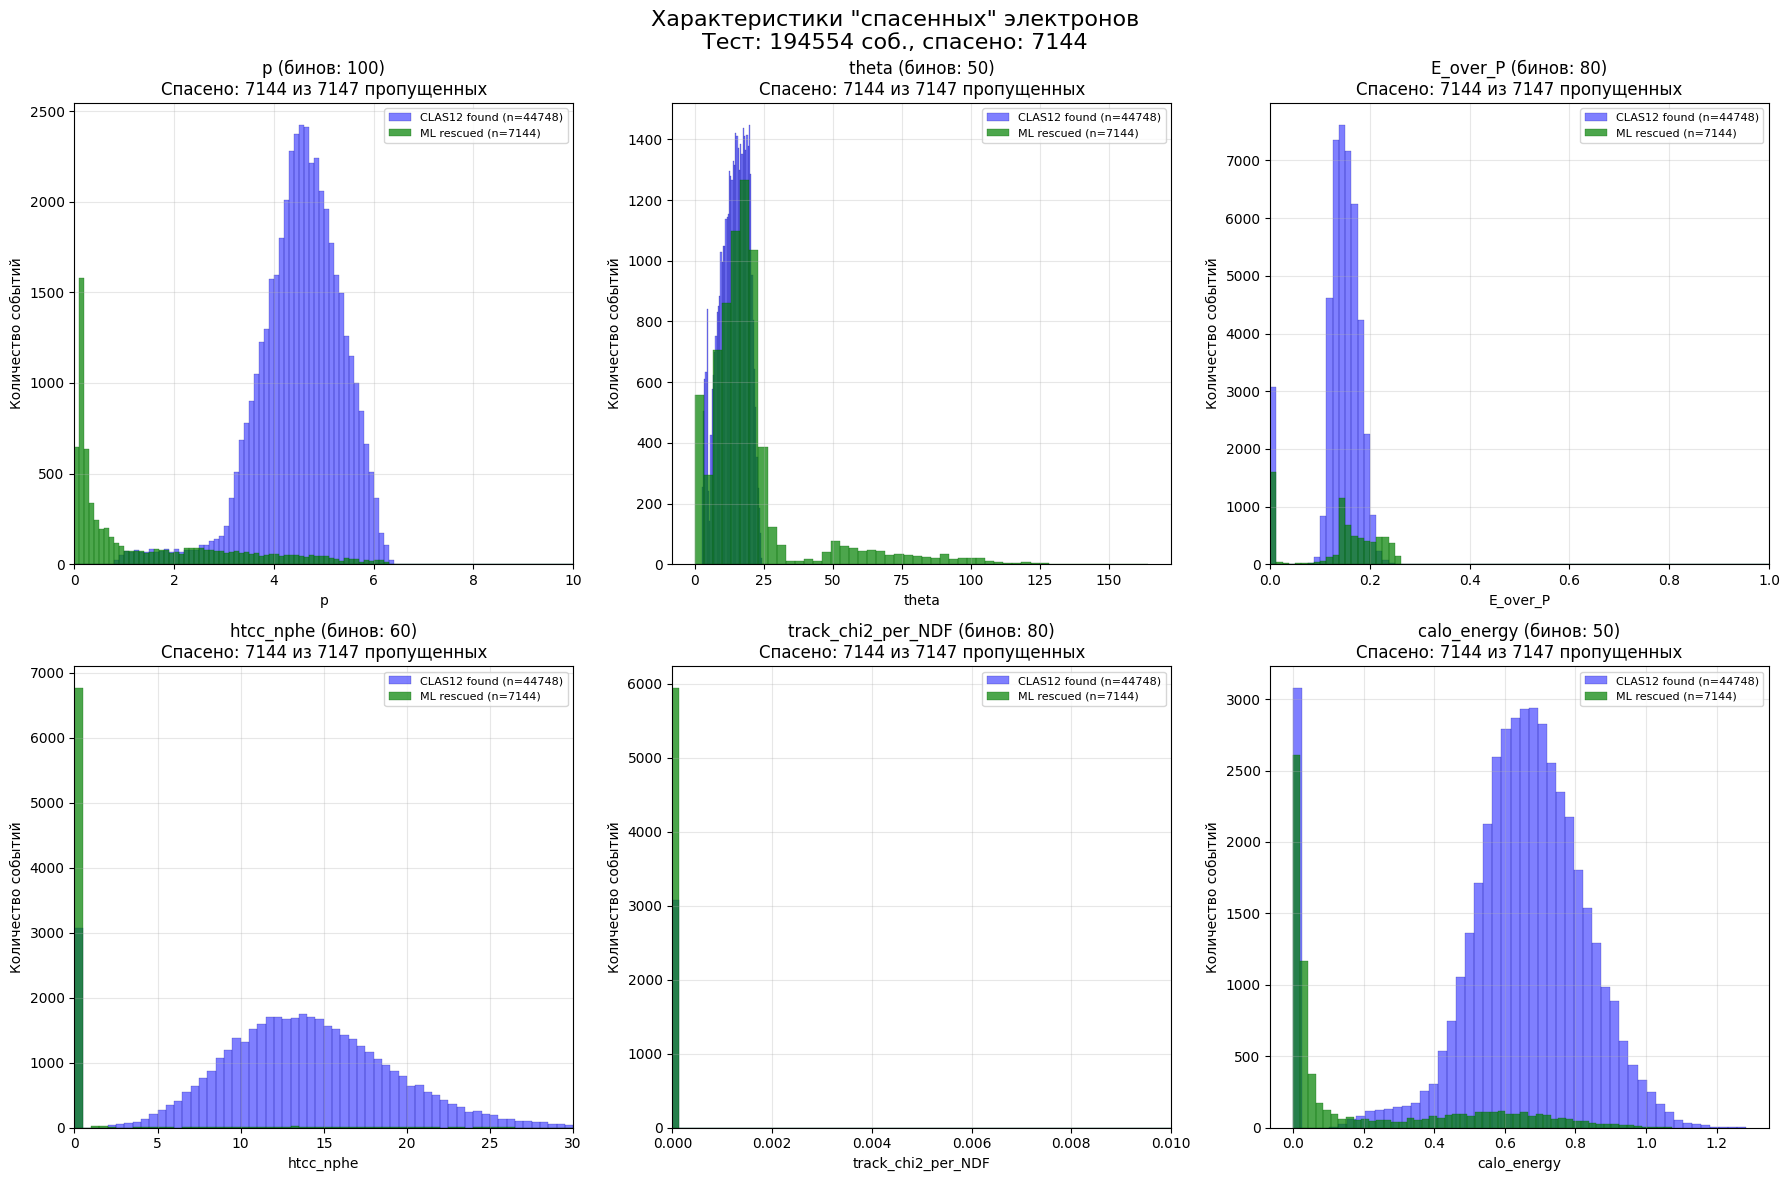


----------------------------------------
РЕЖИМ: УЛУЧШЕНИЕ PRECISION
----------------------------------------
ОЧИЩЕНО фона: 133 из 133 ложных CLAS12 (100.0%)
ПОТЕРЯНО электронов: 16


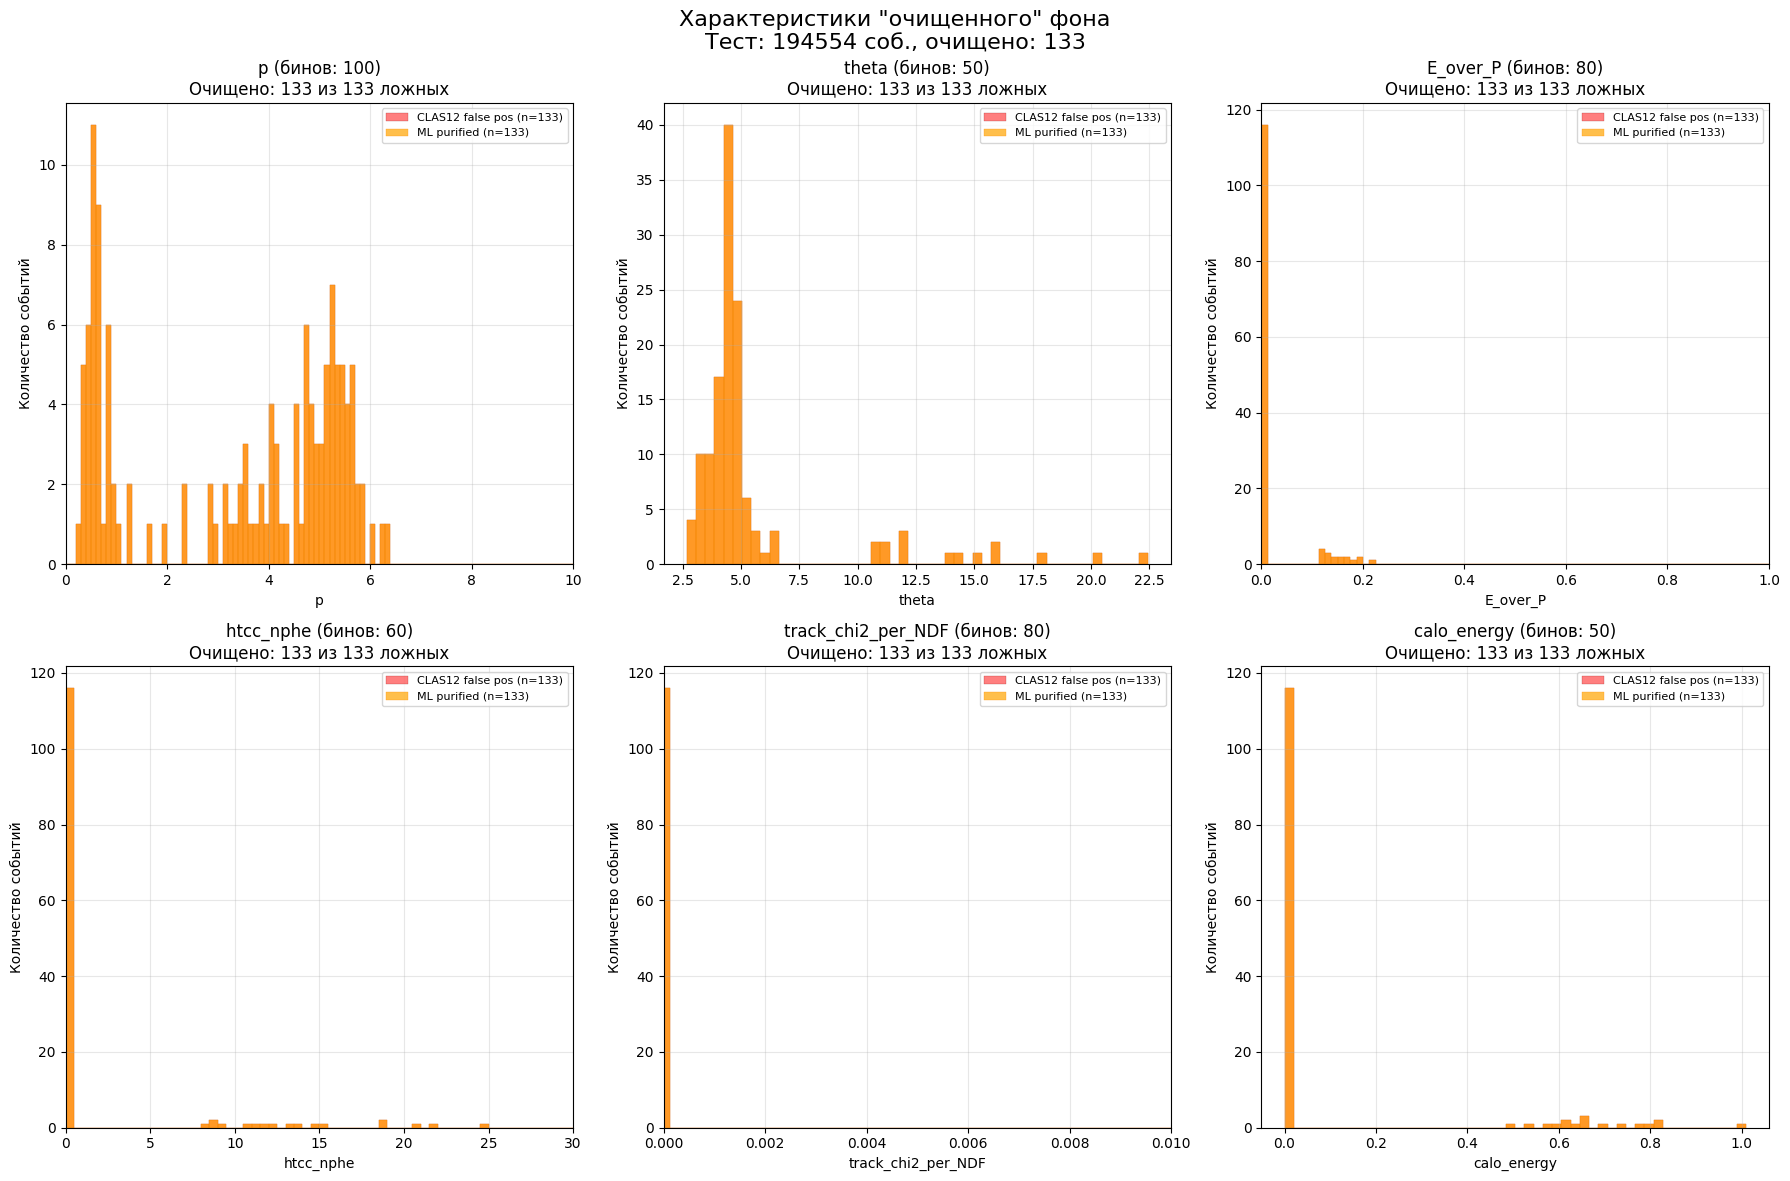


ИТОГОВАЯ СВОДКА
Тестовая выборка: 194554 событий
  Электронов: 51895 (26.7%)
  Фона: 142659

CLAS12:
  Найдено: 44748 | Пропущено: 7147 | Ложных: 133
  Precision: 0.9970 | Recall: 0.8623

Random Forest (High Recall, thr=0.087):
  Спасено: 7144 | Доп. шум: 1102
  Precision: 0.9771 | Recall: 0.9999

Random Forest (High Precision, thr=0.937):
  Убрано шума: 133 | Потеряно: 16
  Precision: 1.0000 | Recall: 0.9327


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, roc_curve, roc_auc_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# Установим русский шрифт для matplotlib
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 10

# Словарь с диапазонами по оси X для разных переменных
x_limits = {
    'p': (0, 10),
    'pt': (0, 10),
    'px': (0, 10),
    'py': (0, 5),
    'pz': (0, 10),
    'E_over_P': (0, 1),
    'htcc_nphe': (0, 30),
    'track_chi2_per_NDF': (0, 0.01),
    'track_chi2': (0, 0.6)
}

# Словарь с количеством бинов для разных переменных
n_bins = {
    'p': 100,
    'pt': 100,
    'px': 100,
    'py': 100,
    'pz': 100,
    'E_over_P': 80,
    'htcc_nphe': 60,
    'track_chi2_per_NDF': 80,
    'track_chi2': 80
}

df = pd.read_csv('clas12_electron_id_features.csv')

print(f"Размер исходного датасета: {df.shape}")
print(f"Истинных электронов (MC) во всем датасете: {df['is_electron_mc'].sum()} ({df['is_electron_mc'].mean()*100:.1f}%)")

# Определяем доступные MC поля
exclude_cols = ['is_electron_mc', 'mc_pid', 'rec_pid']
mc_fields = [col for col in df.columns if col.startswith('mc_')]
exclude_cols.extend(mc_fields)

# Создаем производные переменные
if 'p' not in df.columns:
    df['p'] = np.sqrt(df['px']**2 + df['py']**2 + df['pz']**2)
if 'pt' not in df.columns:
    df['pt'] = np.sqrt(df['px']**2 + df['py']**2)
if 'theta' not in df.columns:
    df['theta'] = np.arccos(df['pz'] / df['p']) * 180 / np.pi
if 'E_over_P' not in df.columns and 'calo_energy' in df.columns:
    df['E_over_P'] = df['calo_energy'] / df['p']
    df['E_over_P'] = df['E_over_P'].replace([np.inf, -np.inf], 0).fillna(0)

# Детальный анализ нулевых импульсов ДО обработки
print("\n" + "="*60)
print("АНАЛИЗ ЭЛЕКТРОНОВ С НУЛЕВЫМ ИМПУЛЬСОМ")
print("="*60)

electron_mask = df['is_electron_mc'] == 1
electrons_df = df[electron_mask]

# Анализ реконструированного импульса
zero_p_rec = electrons_df[electrons_df['p'] == 0]
zero_p_rec_or_nan = electrons_df[(electrons_df['p'] == 0) | (electrons_df['p'].isna())]

print(f"Всего электронов: {len(electrons_df)}")
print(f"Электронов с реконструированным p=0: {len(zero_p_rec)} ({len(zero_p_rec)/len(electrons_df)*100:.2f}%)")

# Проверяем MC импульсы
mc_px_col = 'mc_px' if 'mc_px' in df.columns else None
mc_py_col = 'mc_py' if 'mc_py' in df.columns else None
mc_pz_col = 'mc_pz' if 'mc_pz' in df.columns else None

if all([mc_px_col, mc_py_col, mc_pz_col]):
    # Создаем MC импульс в основном датафрейме
    df['p_mc'] = np.sqrt(df[mc_px_col]**2 + df[mc_py_col]**2 + df[mc_pz_col]**2)
    
    electrons_with_mc = electrons_df.copy()
    electrons_with_mc['p_mc'] = df.loc[electrons_df.index, 'p_mc']
    
    zero_p_mc = electrons_with_mc[electrons_with_mc['p_mc'] == 0]
    zero_p_both = electrons_with_mc[(electrons_with_mc['p_mc'] == 0) & (electrons_with_mc['p'] == 0)]
    
    print(f"Электронов с MC импульсом = 0: {len(zero_p_mc)} ({len(zero_p_mc)/len(electrons_df)*100:.2f}%)")
    print(f"Электронов с обоими импульсами = 0: {len(zero_p_both)}")
    
    if len(zero_p_mc) > 0:
        print("\nПричины нулевых импульсов у электронов:")
        print("1. Мягкие электроны с очень низкой энергией (меньше порога регистрации)")
        print("2. Электроны, рожденные в результате конверсии фотонов в веществе детектора")
        print("3. Вторичные электроны от дельта-электронов с малой энергией")
        print("4. Артефакты реконструкции треков (неудачная фит-процедура)")
        print("5. Частицы, остановившиеся в веществе детектора до калориметра")
        
        if len(zero_p_mc) > 0:
            print(f"\nСредние характеристики электронов с MC p=0:")
            for col in ['theta', 'calo_energy', 'E_over_P']:
                if col in zero_p_mc.columns:
                    valid_data = zero_p_mc[col].dropna()
                    if len(valid_data) > 0:
                        print(f"  {col}: {valid_data.mean():.3f} ± {valid_data.std():.3f}")
        
        # График распределения theta для электронов с p_mc=0
        if len(zero_p_mc) > 0 and 'theta' in zero_p_mc.columns:
            fig, ax = plt.subplots(figsize=(10, 6))
            ax.hist(electrons_df['theta'].dropna(), bins=50, alpha=0.5, 
                   label=f'Все электроны (n={len(electrons_df)})')
            ax.hist(zero_p_mc['theta'].dropna(), bins=50, alpha=0.7, 
                   label=f'Электроны с p_mc=0 (n={len(zero_p_mc)})', color='red')
            ax.set_xlabel('θ (градусы)', fontsize=12)
            ax.set_ylabel('Количество событий', fontsize=12)
            ax.set_title('Угловое распределение электронов с нулевым импульсом', fontsize=14)
            ax.legend()
            ax.grid(True, alpha=0.3)
            plt.tight_layout()
            plt.savefig('zero_momentum_electrons_theta.png', dpi=150, bbox_inches='tight')
            plt.show()

# Продолжаем основную обработку
feature_cols = [col for col in df.columns if col not in exclude_cols]

df_clean = df.dropna(subset=feature_cols + ['is_electron_mc'])
X = df_clean[feature_cols].replace([np.inf, -np.inf], 0).fillna(0)
y_true = df_clean['is_electron_mc']  
y_clas12 = (df_clean['rec_pid'] == 11).astype(int) 

# Разделение выборки
X_train, X_test, y_train, y_test, y_clas12_train, y_clas12_test = train_test_split(
    X, y_true, y_clas12, test_size=0.3, random_state=42, stratify=y_true
)

# Статистика выборок с количеством событий
print("\n" + "="*60)
print("СТАТИСТИКА ВЫБОРОК")
print("="*60)
print(f"Обучающая выборка: {len(X_train)} событий")
print(f"  Электронов: {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"  Фона: {len(y_train) - y_train.sum()}")
print(f"Тестовая выборка: {len(X_test)} событий")
print(f"  Электронов: {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print(f"  Фона: {len(y_test) - y_test.sum()}")

# Оценка CLAS12
print("\nКлассификационный отчет REC::Particle (ТЕСТОВАЯ ВЫБОРКА):")
print(classification_report(y_test, y_clas12_test, target_names=['Фон', 'Электрон']))

cm_clas12 = confusion_matrix(y_test, y_clas12_test)
tn, fp, fn, tp = cm_clas12.ravel()

print(f"Статистика CLAS12 на тестовой выборке ({len(y_test)} событий):")
print(f"True Positives (правильно найденные электроны): {tp}")
print(f"False Negatives (ПРОПУЩЕННЫЕ электроны): {fn} ({fn/(fn+tp)*100:.1f}% от всех электронов)")
print(f"False Positives (ЛОЖНЫЕ электроны): {fp}")
print(f"True Negatives (правильный фон): {tn}")

precision_clas12 = tp / (tp + fp) if (tp + fp) > 0 else 0
recall_clas12 = tp / (tp + fn) if (tp + fn) > 0 else 0
f1_clas12 = 2 * precision_clas12 * recall_clas12 / (precision_clas12 + recall_clas12) if (precision_clas12 + recall_clas12) > 0 else 0

auc_clas12 = roc_auc_score(y_test, y_clas12_test)
fpr_clas12, tpr_clas12, _ = roc_curve(y_test, y_clas12_test)

print(f"\nМетрики CLAS12:")
print(f"Precision: {precision_clas12:.4f}")
print(f"Recall: {recall_clas12:.4f}")
print(f"F1-score: {f1_clas12:.4f}")
print(f"AUC-ROC: {auc_clas12:.4f}")

# Обучение Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=15,
    min_samples_split=10,
    min_samples_leaf=5,
    class_weight='balanced',  
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
y_pred_proba = rf_model.predict_proba(X_test)[:, 1]

auc_rf = roc_auc_score(y_test, y_pred_proba)
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba)

print(f"\nМетрики Random Forest:")
print(f"AUC-ROC: {auc_rf:.4f}")
print(f"Улучшение AUC-ROC относительно CLAS12: +{(auc_rf - auc_clas12)*100:.2f}%")

# Построение деревьев решений с максимальной глубиной 4
print("\n" + "="*60)
print("ДЕРЕВЬЯ РЕШЕНИЙ (макс. глубина = 4)")
print("="*60)

# Дерево без ограничений по классам
dt_simple = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_simple.fit(X_train, y_train)
y_pred_dt_simple = dt_simple.predict(X_test)

print(f"\nПростое дерево (глубина=4) на тесте ({len(y_test)} событий):")
print(classification_report(y_test, y_pred_dt_simple, target_names=['Фон', 'Электрон']))

# Дерево с балансировкой классов
dt_balanced = DecisionTreeClassifier(max_depth=4, class_weight='balanced', random_state=42)
dt_balanced.fit(X_train, y_train)
y_pred_dt_balanced = dt_balanced.predict(X_test)

print(f"\nСбалансированное дерево (глубина=4) на тесте ({len(y_test)} событий):")
print(classification_report(y_test, y_pred_dt_balanced, target_names=['Фон', 'Электрон']))

# Визуализация деревьев
fig, axes = plt.subplots(1, 2, figsize=(24, 10))

# Простое дерево
plot_tree(dt_simple, 
          feature_names=feature_cols,
          class_names=['Фон', 'Электрон'],
          filled=True, 
          rounded=True,
          fontsize=8,
          ax=axes[0])
axes[0].set_title(f'Простое дерево решений (глубина=4)\nОбучающая выборка: {len(X_train)} событий', 
                  fontsize=14)

# Сбалансированное дерево
plot_tree(dt_balanced,
          feature_names=feature_cols,
          class_names=['Фон', 'Электрон'],
          filled=True,
          rounded=True,
          fontsize=8,
          ax=axes[1])
axes[1].set_title(f'Сбалансированное дерево решений (глубина=4)\nОбучающая выборка: {len(X_train)} событий', 
                  fontsize=14)

plt.tight_layout()
plt.savefig('decision_trees_depth4.png', dpi=150, bbox_inches='tight')
plt.show()

# Важность признаков в деревьях
feature_importance_tree = pd.DataFrame({
    'feature': feature_cols,
    'importance_simple': dt_simple.feature_importances_,
    'importance_balanced': dt_balanced.feature_importances_
}).sort_values('importance_simple', ascending=False)

print("\nТоп-10 признаков для простого дерева:")
print(feature_importance_tree[['feature', 'importance_simple']].head(10))

print("\nТоп-10 признаков для сбалансированного дерева:")
print(feature_importance_tree[['feature', 'importance_balanced']].head(10))

# Precision-Recall кривая и оптимизация порогов
precision_curve, recall_curve, thresholds = precision_recall_curve(y_test, y_pred_proba)

# 1. Максимальный Recall при Precision не ниже CLAS12
target_precision = precision_clas12 * 0.98
valid_idx = np.where(precision_curve[:-1] >= target_precision)[0]
if len(valid_idx) > 0:
    best_recall_idx = valid_idx[recall_curve[:-1][valid_idx].argmax()]
    threshold_high_recall = thresholds[best_recall_idx]
    precision_high_recall = precision_curve[best_recall_idx]
    recall_high_recall = recall_curve[best_recall_idx]
else:
    threshold_high_recall = 0.5
    precision_high_recall = precision_curve[-1]
    recall_high_recall = recall_curve[-1]

# 2. Максимальный Precision при Recall не ниже CLAS12
target_recall = recall_clas12 * 1.02
valid_idx2 = np.where(recall_curve[:-1] >= target_recall)[0]
if len(valid_idx2) > 0:
    best_precision_idx = valid_idx2[precision_curve[:-1][valid_idx2].argmax()]
    threshold_high_precision = thresholds[best_precision_idx]
    precision_high_precision = precision_curve[best_precision_idx]
    recall_high_precision = recall_curve[best_precision_idx]
else:
    threshold_high_precision = 0.7
    precision_high_precision = precision_curve[0]
    recall_high_precision = recall_curve[0]

print(f"\nВарианты порогов (всего событий в тесте: {len(y_test)}):")
print(f"1. Приоритет Recall: threshold={threshold_high_recall:.3f}")
print(f"   Precision: {precision_high_recall:.4f} (CLAS12: {precision_clas12:.4f})")
print(f"   Recall: {recall_high_recall:.4f} (CLAS12: {recall_clas12:.4f})")
print(f"   Улучшение Recall: +{(recall_high_recall - recall_clas12)*100:.1f}%")

print(f"\n2. Приоритет Precision: threshold={threshold_high_precision:.3f}")
print(f"   Precision: {precision_high_precision:.4f} (CLAS12: {precision_clas12:.4f})")
print(f"   Recall: {recall_high_precision:.4f} (CLAS12: {recall_clas12:.4f})")
print(f"   Улучшение Precision: +{(precision_high_precision - precision_clas12)*100:.1f}%")

# Графики с добавленной статистикой
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Precision-Recall кривая со статистикой
axes[0].plot(recall_curve, precision_curve, 'b-', linewidth=2, 
             label=f'RF (AUC={auc_rf:.3f})')
axes[0].scatter(recall_clas12, precision_clas12, color='red', s=200, 
                marker='*', label=f'CLAS12\nP={precision_clas12:.3f}, R={recall_clas12:.3f}', 
                zorder=5, edgecolors='darkred')
axes[0].scatter(recall_high_recall, precision_high_recall, color='green', s=150, 
                marker='s', label=f'High Recall\nP={precision_high_recall:.3f}, R={recall_high_recall:.3f}', 
                zorder=5)
axes[0].scatter(recall_high_precision, precision_high_precision, color='orange', s=150, 
                marker='^', label=f'High Precision\nP={precision_high_precision:.3f}, R={recall_high_precision:.3f}', 
                zorder=5)
axes[0].set_xlabel('Recall (Полнота)', fontsize=12)
axes[0].set_ylabel('Precision (Точность)', fontsize=12)
axes[0].set_title(f'Precision-Recall\nТест: {len(y_test)} соб. (e={y_test.sum()}, фон={len(y_test)-y_test.sum()})', 
                  fontsize=14)
axes[0].legend(fontsize=9, loc='lower left')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0.8, 1.01])
axes[0].set_ylim([0.9, 1.01])

# ROC-кривые со статистикой
axes[1].plot(fpr_clas12, tpr_clas12, 'r-', linewidth=2, 
             label=f'CLAS12\nAUC={auc_clas12:.4f}\nTP={tp}, FP={fp}, FN={fn}, TN={tn}')
axes[1].plot(fpr_rf, tpr_rf, 'b-', linewidth=2, 
             label=f'RF\nAUC={auc_rf:.4f}')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, label='Случайный')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate', fontsize=12)
axes[1].set_title(f'ROC-кривые\nТест: {len(y_test)} событий', fontsize=14)
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

# Зависимость метрик от порога со статистикой
axes[2].plot(thresholds, precision_curve[:-1], 'b-', label='Precision', linewidth=2)
axes[2].plot(thresholds, recall_curve[:-1], 'r-', label='Recall', linewidth=2)
axes[2].axvline(x=threshold_high_recall, color='green', linestyle='--', 
                label=f'High Recall: {threshold_high_recall:.3f}')
axes[2].axvline(x=threshold_high_precision, color='orange', linestyle='--', 
                label=f'High Precision: {threshold_high_precision:.3f}')
axes[2].set_xlabel('Threshold', fontsize=12)
axes[2].set_ylabel('Score', fontsize=12)
axes[2].set_title(f'Precision/Recall vs Threshold\nТест: {len(y_test)} событий', fontsize=14)
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('precision_recall_optimization_with_stats.png', dpi=150, bbox_inches='tight')
plt.show()

# Гистограммы в нормальном масштабе для каждой физической величины
print("\n" + "="*60)
print("ГИСТОГРАММЫ ФИЗИЧЕСКИХ ВЕЛИЧИН (НОРМАЛЬНЫЙ МАСШТАБ)")
print("="*60)

# Определяем основные физические величины (без MC полей)
physics_vars = ['p', 'pt', 'px', 'py', 'pz', 'theta', 'E_over_P', 'calo_energy']
if 'htcc_nphe' in df_clean.columns:
    physics_vars.append('htcc_nphe')
if 'track_chi2_per_NDF' in df_clean.columns:
    physics_vars.append('track_chi2_per_NDF')
if 'track_chi2' in df_clean.columns:
    physics_vars.append('track_chi2')

# Создаем подвыборки для гистограмм
df_test_analysis = df_clean.iloc[y_test.index].copy()
df_test_analysis['true_class'] = 'Фон'
df_test_analysis.loc[y_test == 1, 'true_class'] = 'Электрон'

# Строим гистограммы
n_vars = min(len(physics_vars), 12)
n_rows = (n_vars + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(18, 5*n_rows))
axes = axes.flatten() if n_rows > 1 else [axes] if n_vars == 1 else axes

for idx, var in enumerate(physics_vars[:12]):
    if var in df_test_analysis.columns:
        ax = axes[idx]
        
        # Данные для разных категорий
        electrons = df_test_analysis[df_test_analysis['true_class'] == 'Электрон'][var].dropna()
        background = df_test_analysis[df_test_analysis['true_class'] == 'Фон'][var].dropna()
        
        # Определяем количество бинов
        bins = n_bins.get(var, 50)
        
        # Если есть ограничения по X, создаем бины в пределах диапазона
        if var in x_limits:
            x_min, x_max = x_limits[var]
            # Создаем равномерные бины в заданном диапазоне
            bin_edges = np.linspace(x_min, x_max, bins + 1)
            
            # Обрезаем данные по диапазону для корректного отображения
            background_clipped = background[(background >= x_min) & (background <= x_max)]
            electrons_clipped = electrons[(electrons >= x_min) & (electrons <= x_max)]
            
            # Строим гистограммы с явно заданными границами бинов
            ax.hist(background_clipped, bins=bin_edges, alpha=0.5, 
                    label=f'Фон (всего: {len(background)}, показано: {len(background_clipped)})', 
                    density=False, color='red', edgecolor='darkred', linewidth=0.3)
            ax.hist(electrons_clipped, bins=bin_edges, alpha=0.5, 
                    label=f'Электроны (всего: {len(electrons)}, показано: {len(electrons_clipped)})', 
                    density=False, color='blue', edgecolor='darkblue', linewidth=0.3)
        else:
            # Для переменных без ограничений используем обычный подход
            ax.hist(background, bins=bins, alpha=0.5, 
                    label=f'Фон (n={len(background)})', 
                    density=False, color='red', edgecolor='darkred', linewidth=0.3)
            ax.hist(electrons, bins=bins, alpha=0.5, 
                    label=f'Электроны (n={len(electrons)})', 
                    density=False, color='blue', edgecolor='darkblue', linewidth=0.3)
        
        # Применяем ограничения по оси X из словаря
        if var in x_limits:
            ax.set_xlim(x_limits[var])
        
        ax.set_xlabel(var, fontsize=10)
        ax.set_ylabel('Количество событий', fontsize=10)
        ax.set_title(f'{var} (бинов: {bins})\nВсего: {len(electrons)+len(background)} соб.', fontsize=11)
        ax.legend(fontsize=7)
        ax.grid(True, alpha=0.3)
        
        # Добавляем статистику
        if len(electrons) > 0 and len(background) > 0:
            stats_text = f'μ_e={electrons.mean():.2f}\nσ_e={electrons.std():.2f}\nμ_b={background.mean():.2f}\nσ_b={background.std():.2f}'
            ax.text(0.02, 0.98, stats_text, transform=ax.transAxes, 
                    fontsize=7, verticalalignment='top',
                    bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.5))

# Убираем пустые подграфики
for idx in range(len(physics_vars), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle(f'Распределения физических величин (нормальный масштаб, увеличенные бины)\nТестовая выборка: {len(y_test)} событий', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('physics_distributions_normal_scale.png', dpi=150, bbox_inches='tight')
plt.show()

# Анализ ошибок и спасенных частиц
y_pred_high_recall = (y_pred_proba >= threshold_high_recall).astype(int)
y_pred_high_precision = (y_pred_proba >= threshold_high_precision).astype(int)

df_test = df_clean.iloc[y_test.index].copy()
df_test['clas12_pred'] = y_clas12_test.values
df_test['rf_prob'] = y_pred_proba
df_test['rf_high_recall'] = y_pred_high_recall
df_test['rf_high_precision'] = y_pred_high_precision

print("\n" + "-" * 40)
print("РЕЖИМ: УЛУЧШЕНИЕ RECALL")
print("-" * 40)

rescued_mask = (df_test['clas12_pred'] == 0) & (df_test['rf_high_recall'] == 1) & (y_test == 1)
rescued = df_test[rescued_mask]

extra_noise_mask = (df_test['clas12_pred'] == 0) & (df_test['rf_high_recall'] == 1) & (y_test == 0)
extra_noise = df_test[extra_noise_mask]

print(f"СПАСЕНО электронов: {len(rescued)} из {fn} пропущенных CLAS12 (+{len(rescued)/fn*100:.1f}%)")
print(f"ДОБАВЛЕНО шума: {len(extra_noise)}")

# Анализ спасенных с нулевым импульсом
if len(rescued) > 0:
    zero_p_rescued = rescued[rescued['p'] == 0]
    print(f"Из них с p=0: {len(zero_p_rescued)} ({len(zero_p_rescued)/len(rescued)*100:.1f}%)")
    
    # Графики характеристик спасенных электронов
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    variables = ['p', 'theta', 'E_over_P']
    if 'htcc_nphe' in df_test.columns:
        variables.append('htcc_nphe')
    if 'track_chi2_per_NDF' in df_test.columns:
        variables.append('track_chi2_per_NDF')
    if 'calo_energy' in df_test.columns:
        variables.append('calo_energy')
    
    found_by_clas12 = df_test[(df_test['clas12_pred'] == 1) & (y_test == 1)]
    
    for ax, var in zip(axes.flatten(), variables[:6]):
        if var in df_test.columns:
            # Определяем количество бинов
            bins = n_bins.get(var, 50)
            
            # Если есть ограничения по X, создаем бины в пределах диапазона
            if var in x_limits:
                x_min, x_max = x_limits[var]
                bin_edges = np.linspace(x_min, x_max, bins + 1)
                
                clas12_data = found_by_clas12[var].dropna()
                rescued_data = rescued[var].dropna()
                
                clas12_clipped = clas12_data[(clas12_data >= x_min) & (clas12_data <= x_max)]
                rescued_clipped = rescued_data[(rescued_data >= x_min) & (rescued_data <= x_max)]
                
                ax.hist(clas12_clipped, bins=bin_edges, alpha=0.5, 
                        label=f'CLAS12 found (n={len(found_by_clas12)})', 
                        density=False, color='blue', edgecolor='darkblue', linewidth=0.3)
                ax.hist(rescued_clipped, bins=bin_edges, alpha=0.7, 
                        label=f'ML rescued (n={len(rescued)})', 
                        density=False, color='green', edgecolor='darkgreen', linewidth=0.3)
            else:
                ax.hist(found_by_clas12[var].dropna(), bins=bins, alpha=0.5, 
                        label=f'CLAS12 found (n={len(found_by_clas12)})', 
                        density=False, color='blue', edgecolor='darkblue', linewidth=0.3)
                ax.hist(rescued[var].dropna(), bins=bins, alpha=0.7, 
                        label=f'ML rescued (n={len(rescued)})', 
                        density=False, color='green', edgecolor='darkgreen', linewidth=0.3)
            
            ax.set_xlabel(var, fontsize=10)
            ax.set_ylabel('Количество событий', fontsize=10)
            ax.legend(fontsize=8)
            ax.set_title(f'{var} (бинов: {bins})\nСпасено: {len(rescued)} из {fn} пропущенных')
            ax.grid(True, alpha=0.3)
            
            # Добавляем ограничения по оси X
            if var in x_limits:
                ax.set_xlim(x_limits[var])
    
    plt.suptitle(f'Характеристики "спасенных" электронов\nТест: {len(y_test)} соб., спасено: {len(rescued)}', 
                 fontsize=16)
    plt.tight_layout()
    plt.savefig('rescued_electrons.png', dpi=150, bbox_inches='tight')
    plt.show()

print("\n" + "-" * 40)
print("РЕЖИМ: УЛУЧШЕНИЕ PRECISION")
print("-" * 40)

purified_mask = (df_test['clas12_pred'] == 1) & (df_test['rf_high_precision'] == 0) & (y_test == 0)
purified = df_test[purified_mask]

lost_mask = (df_test['clas12_pred'] == 1) & (df_test['rf_high_precision'] == 0) & (y_test == 1)
lost = df_test[lost_mask]

print(f"ОЧИЩЕНО фона: {len(purified)} из {fp} ложных CLAS12 ({len(purified)/fp*100:.1f}%)")
print(f"ПОТЕРЯНО электронов: {len(lost)}")

if len(purified) > 0:
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    variables = ['p', 'theta', 'E_over_P']
    if 'htcc_nphe' in df_test.columns:
        variables.append('htcc_nphe')
    if 'track_chi2_per_NDF' in df_test.columns:
        variables.append('track_chi2_per_NDF')
    if 'calo_energy' in df_test.columns:
        variables.append('calo_energy')
    
    false_positives = df_test[(df_test['clas12_pred'] == 1) & (y_test == 0)]
    
    for ax, var in zip(axes.flatten(), variables[:6]):
        if var in df_test.columns:
            # Определяем количество бинов
            bins = n_bins.get(var, 50)
            
            # Если есть ограничения по X, создаем бины в пределах диапазона
            if var in x_limits:
                x_min, x_max = x_limits[var]
                bin_edges = np.linspace(x_min, x_max, bins + 1)
                
                fp_data = false_positives[var].dropna()
                purified_data = purified[var].dropna()
                
                fp_clipped = fp_data[(fp_data >= x_min) & (fp_data <= x_max)]
                purified_clipped = purified_data[(purified_data >= x_min) & (purified_data <= x_max)]
                
                ax.hist(fp_clipped, bins=bin_edges, alpha=0.5, 
                        label=f'CLAS12 false pos (n={len(false_positives)})', 
                        density=False, color='red', edgecolor='darkred', linewidth=0.3)
                ax.hist(purified_clipped, bins=bin_edges, alpha=0.7, 
                        label=f'ML purified (n={len(purified)})', 
                        density=False, color='orange', edgecolor='darkorange', linewidth=0.3)
            else:
                ax.hist(false_positives[var].dropna(), bins=bins, alpha=0.5, 
                        label=f'CLAS12 false pos (n={len(false_positives)})', 
                        density=False, color='red', edgecolor='darkred', linewidth=0.3)
                ax.hist(purified[var].dropna(), bins=bins, alpha=0.7, 
                        label=f'ML purified (n={len(purified)})', 
                        density=False, color='orange', edgecolor='darkorange', linewidth=0.3)
            
            ax.set_xlabel(var, fontsize=10)
            ax.set_ylabel('Количество событий', fontsize=10)
            ax.legend(fontsize=8)
            ax.set_title(f'{var} (бинов: {bins})\nОчищено: {len(purified)} из {fp} ложных')
            ax.grid(True, alpha=0.3)
            
            # Добавляем ограничения по оси X
            if var in x_limits:
                ax.set_xlim(x_limits[var])
    
    plt.suptitle(f'Характеристики "очищенного" фона\nТест: {len(y_test)} соб., очищено: {len(purified)}', 
                 fontsize=16)
    plt.tight_layout()
    plt.savefig('purified_background.png', dpi=150, bbox_inches='tight')
    plt.show()

# Итоговая сводка
print("\n" + "="*60)
print("ИТОГОВАЯ СВОДКА")
print("="*60)
print(f"Тестовая выборка: {len(y_test)} событий")
print(f"  Электронов: {y_test.sum()} ({y_test.mean()*100:.1f}%)")
print(f"  Фона: {len(y_test) - y_test.sum()}")
print(f"\nCLAS12:")
print(f"  Найдено: {tp} | Пропущено: {fn} | Ложных: {fp}")
print(f"  Precision: {precision_clas12:.4f} | Recall: {recall_clas12:.4f}")
print(f"\nRandom Forest (High Recall, thr={threshold_high_recall:.3f}):")
print(f"  Спасено: {len(rescued)} | Доп. шум: {len(extra_noise)}")
print(f"  Precision: {precision_high_recall:.4f} | Recall: {recall_high_recall:.4f}")
print(f"\nRandom Forest (High Precision, thr={threshold_high_precision:.3f}):")
print(f"  Убрано шума: {len(purified)} | Потеряно: {len(lost)}")
print(f"  Precision: {precision_high_precision:.4f} | Recall: {recall_high_precision:.4f}")